# Fitting coherent T1/T2 decay
Run cells in order. Configure paths and switches in cell 1.

## 1. Data loading and plotting

c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


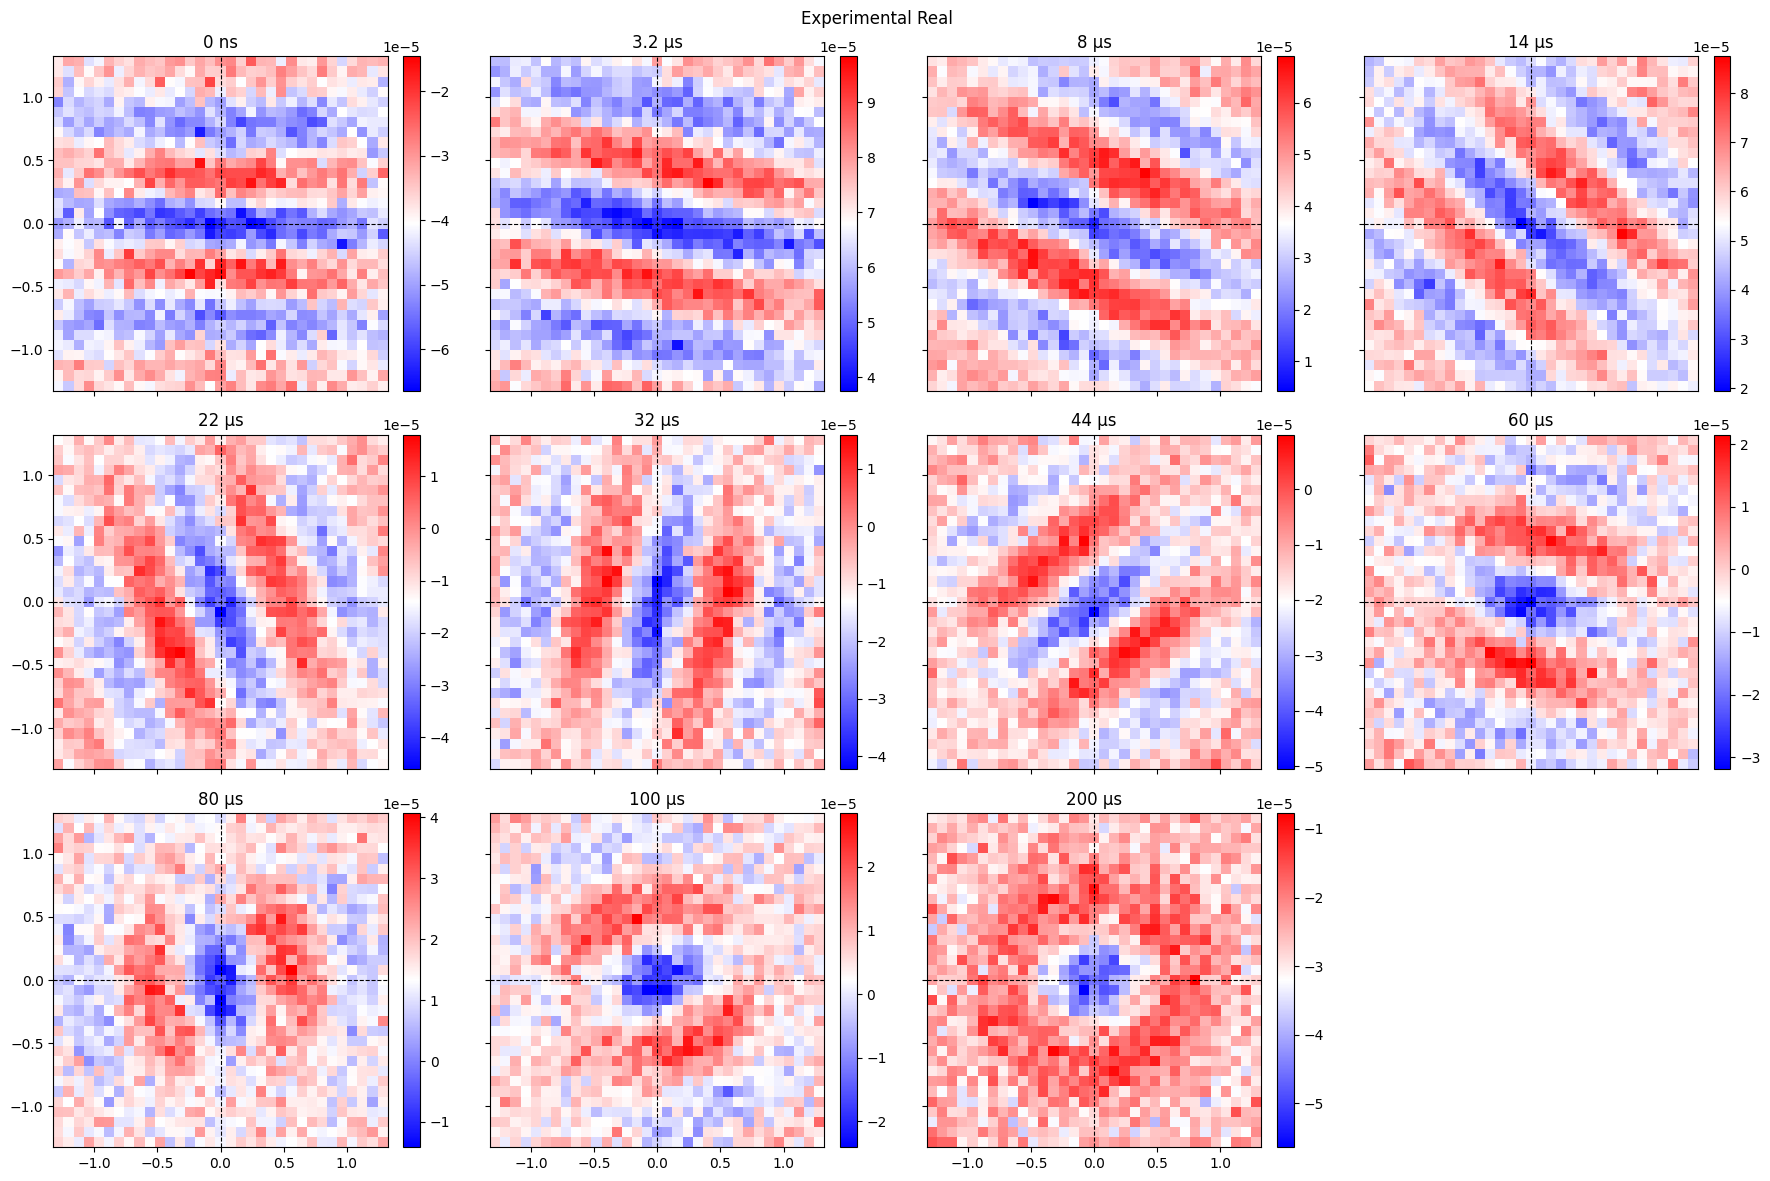

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from helpers.io import load_experiment, load_processed_npz
from helpers.plotting import plot_characteristic_functions, plot_landscape
from helpers.simulation import CharacteristicFunctionSimulator
from helpers.comparison import build_mask, residue, residue_no_rotation, compare_experiment_simulation, extract_rotation_angles, build_time_weights
from helpers.fitting import find_best_alpha
from helpers.optimizer import optimize_parameters
postprocess = False
fit_first_independent = True
time_weight_exponent = 1
Real_part, Imag_part = True, False
if not (Real_part or Imag_part): raise ValueError('Select at least one component.')

if postprocess:
    # Processed NPZ files already contain calibrated beta axes.
    processed_data_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_3'
    delay_times_ns = np.array([0, 10_000, 20_000, 30_000, 40_000, 50_000], dtype=float)
    DELAY_INDICES = 'all'
    beta_scale = 1.0
    state_list_real, state_list_imag, x_list, y_list, decay_sweep_sorted = load_processed_npz(processed_data_dir, delay_times_ns, DELAY_INDICES, beta_scale)
    print(f'Loaded {len(decay_sweep_sorted)} processed NPZ datasets; beta_scale={beta_scale}.')
else:
    # Original raw HDF5 loading path.
    beta_scale, experiment_start = 1.603359375, '00-00-01'#'20-01-00'
    real_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_1\\data_real' if Real_part else None
    imag_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_1\\data_img' if Imag_part else None
    real_decays = np.array([25_000, 800, 50_000, 2_000, 3_500, 0, 5_500, 8_000, 11_000, 15_000, 20_000])*4  if Real_part else None #np.array([4,7000,14000,21000])*4
    imag_decays = np.array([20_000, 25_000, 800, 50_000, 2_000, 3_500, 0, 5_500, 8_000, 11_000, 15_000])*4    if Imag_part else None
    state_list_real, state_list_imag, x_list, y_list, decay_sweep_sorted = load_experiment(real_dir, imag_dir, real_decays, imag_decays, beta_scale, experiment_start)
independent_first = postprocess and fit_first_independent
weights = build_time_weights(decay_sweep_sorted, time_weight_exponent)

exp_data = (state_list_real,state_list_imag) if Real_part and Imag_part else (state_list_real if Real_part else state_list_imag)
if Real_part: plot_characteristic_functions(state_list_real,x_list,y_list,decay_sweep_sorted,'Experimental Real')
if Imag_part: plot_characteristic_functions(state_list_imag,x_list,y_list,decay_sweep_sorted,'Experimental Imaginary')

## 2. Simulation

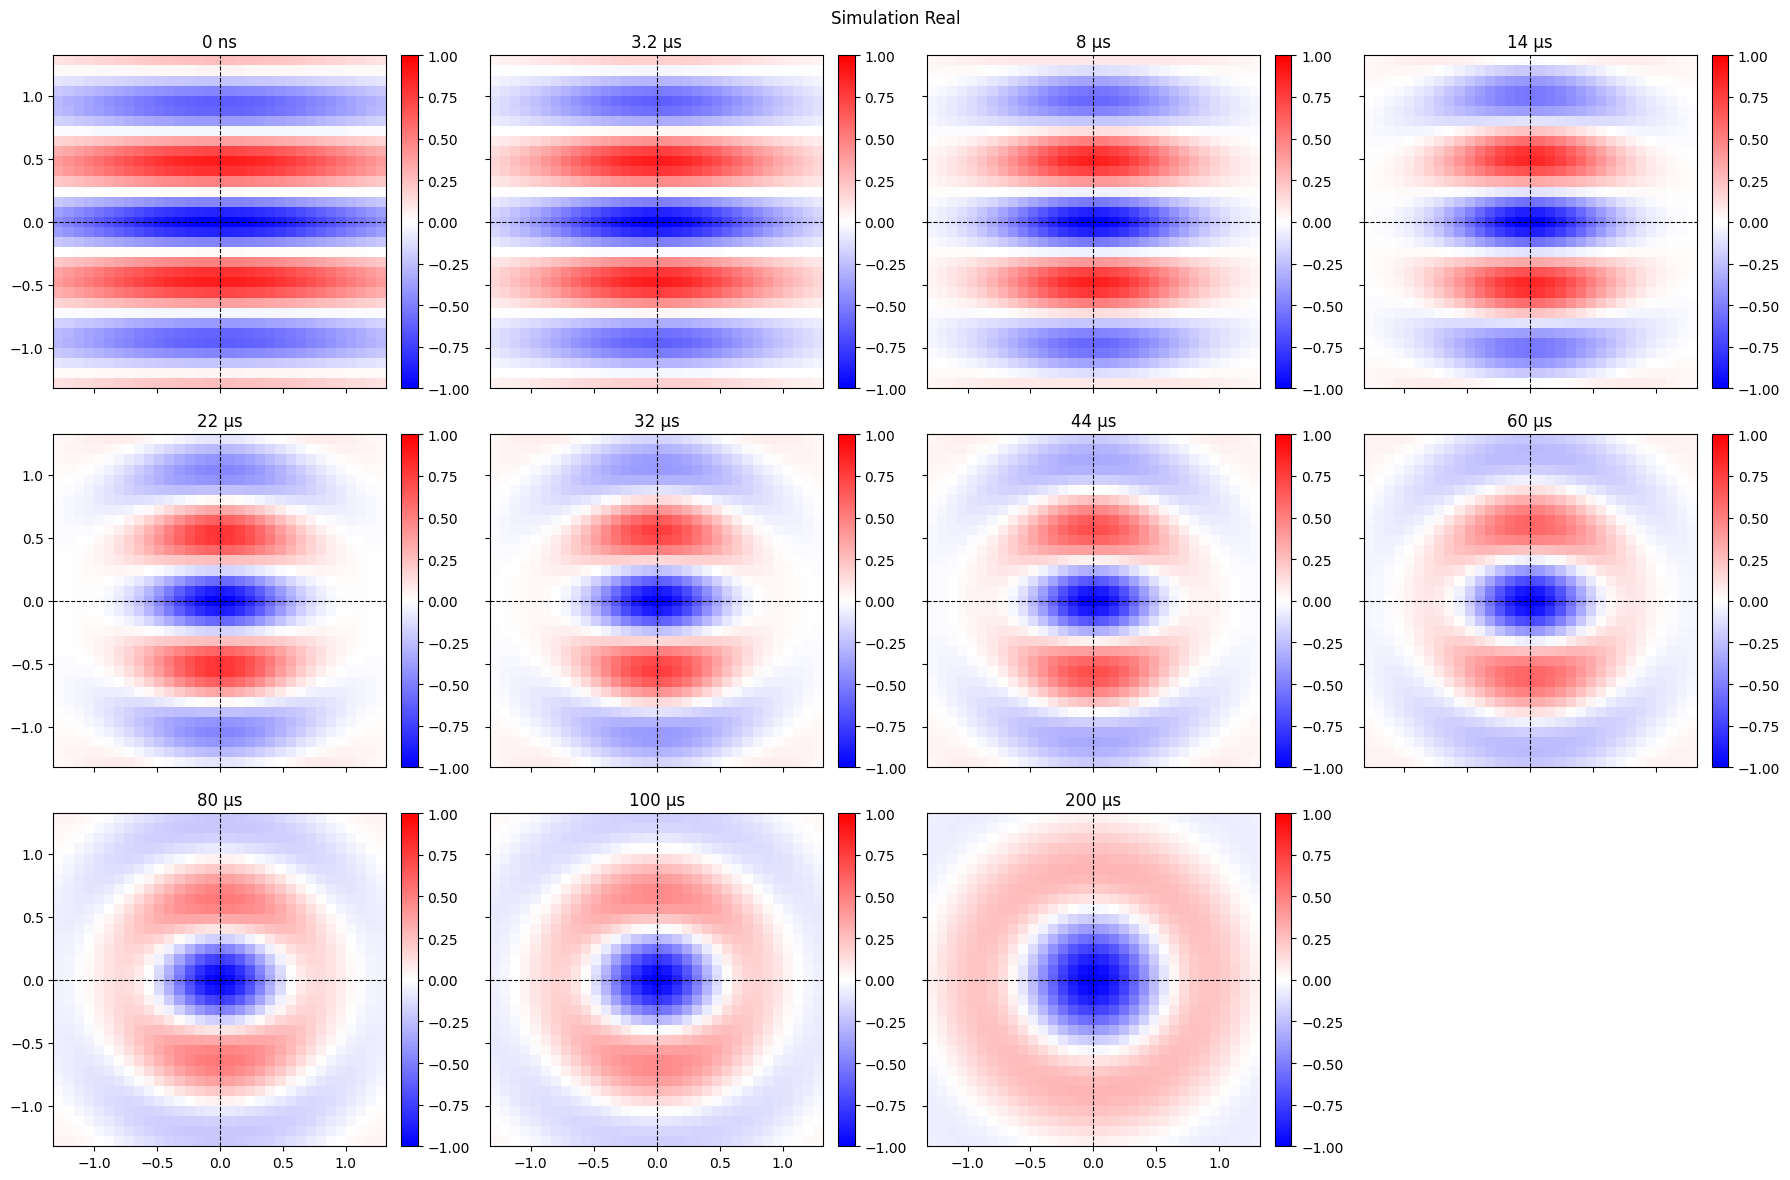

In [3]:
N_c = 50
simulator = CharacteristicFunctionSimulator(N_c,x_list[0],y_list[0])
T1, T2, alpha = 200_000, 160_000, 3.3
charfunc_sim = simulator.simulate(decay_sweep_sorted,T1,T2,alpha=alpha,return_real=Real_part,return_imag=Imag_part)
if Real_part: plot_characteristic_functions(charfunc_sim[0] if Imag_part else charfunc_sim,x_list,y_list,decay_sweep_sorted,'Simulation Real', vmin=-1, vmax=1)
if Imag_part: plot_characteristic_functions(charfunc_sim[1] if Real_part else charfunc_sim,x_list,y_list,decay_sweep_sorted,'Simulation Imaginary', vmin=-1, vmax=1)

## 3. Fit alpha and rotation

Searching alpha...
alpha=3.9625, angle=-178.00 deg, cost=0.254405


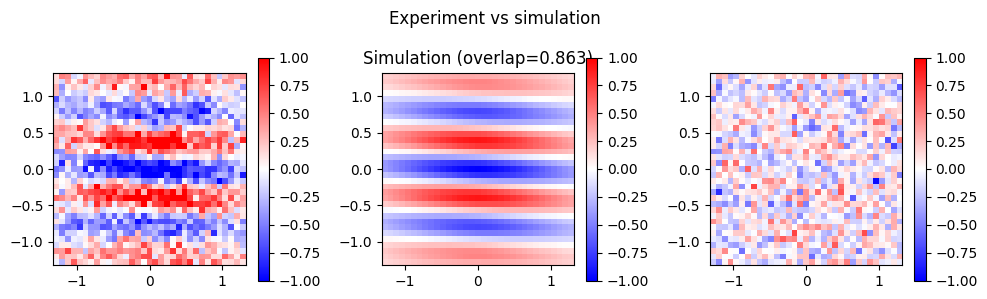

(array([-178.]), array([0.86283295]))

In [4]:
mask = build_mask(x_list[0],y_list[0],2.5)
alpha_values = np.linspace(3.0,4.0,81); rotation_values = np.linspace(-180.0,180.0,361)
alpha_fit = find_best_alpha(simulator,exp_data,np.array([decay_sweep_sorted[0]]),alpha_values,rotation_values,mask,component=('real' if Real_part else 'imag'))
initial_alpha, initial_angle = alpha_fit['alpha'], alpha_fit['angle']
print(f'alpha={initial_alpha:.4f}, angle={initial_angle:.2f} deg, cost={alpha_fit["cost"]:.6f}')
alpha_exp_data = (state_list_real[:1], state_list_imag[:1]) if Real_part and Imag_part else (state_list_real[:1] if Real_part else state_list_imag[:1])
compare_experiment_simulation(alpha_exp_data,alpha_fit['sim'],x_list[:1],y_list[:1],mask,weights=weights[:1],rotate_images=True,rotation_angles=rotation_values,first_angle=(initial_angle if independent_first else None))

## 4. Coarse T1/T2 grid search

Grid result: T1=205.556 us, T2=244.444 us, residue=0.420736


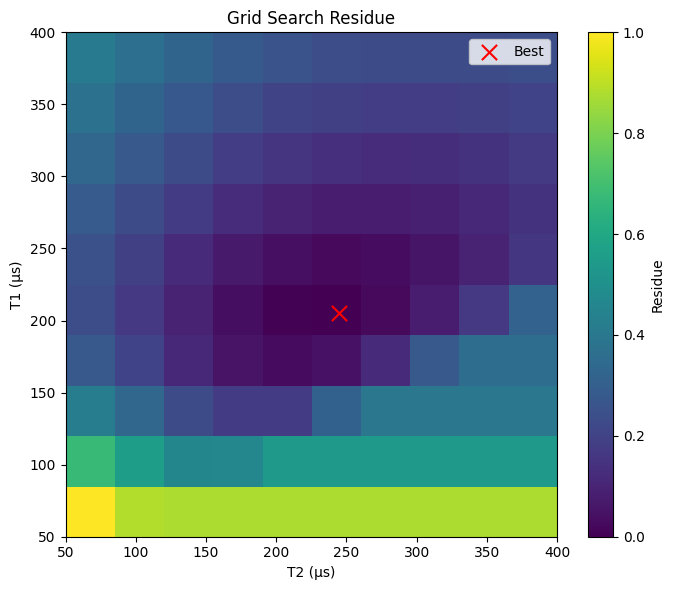

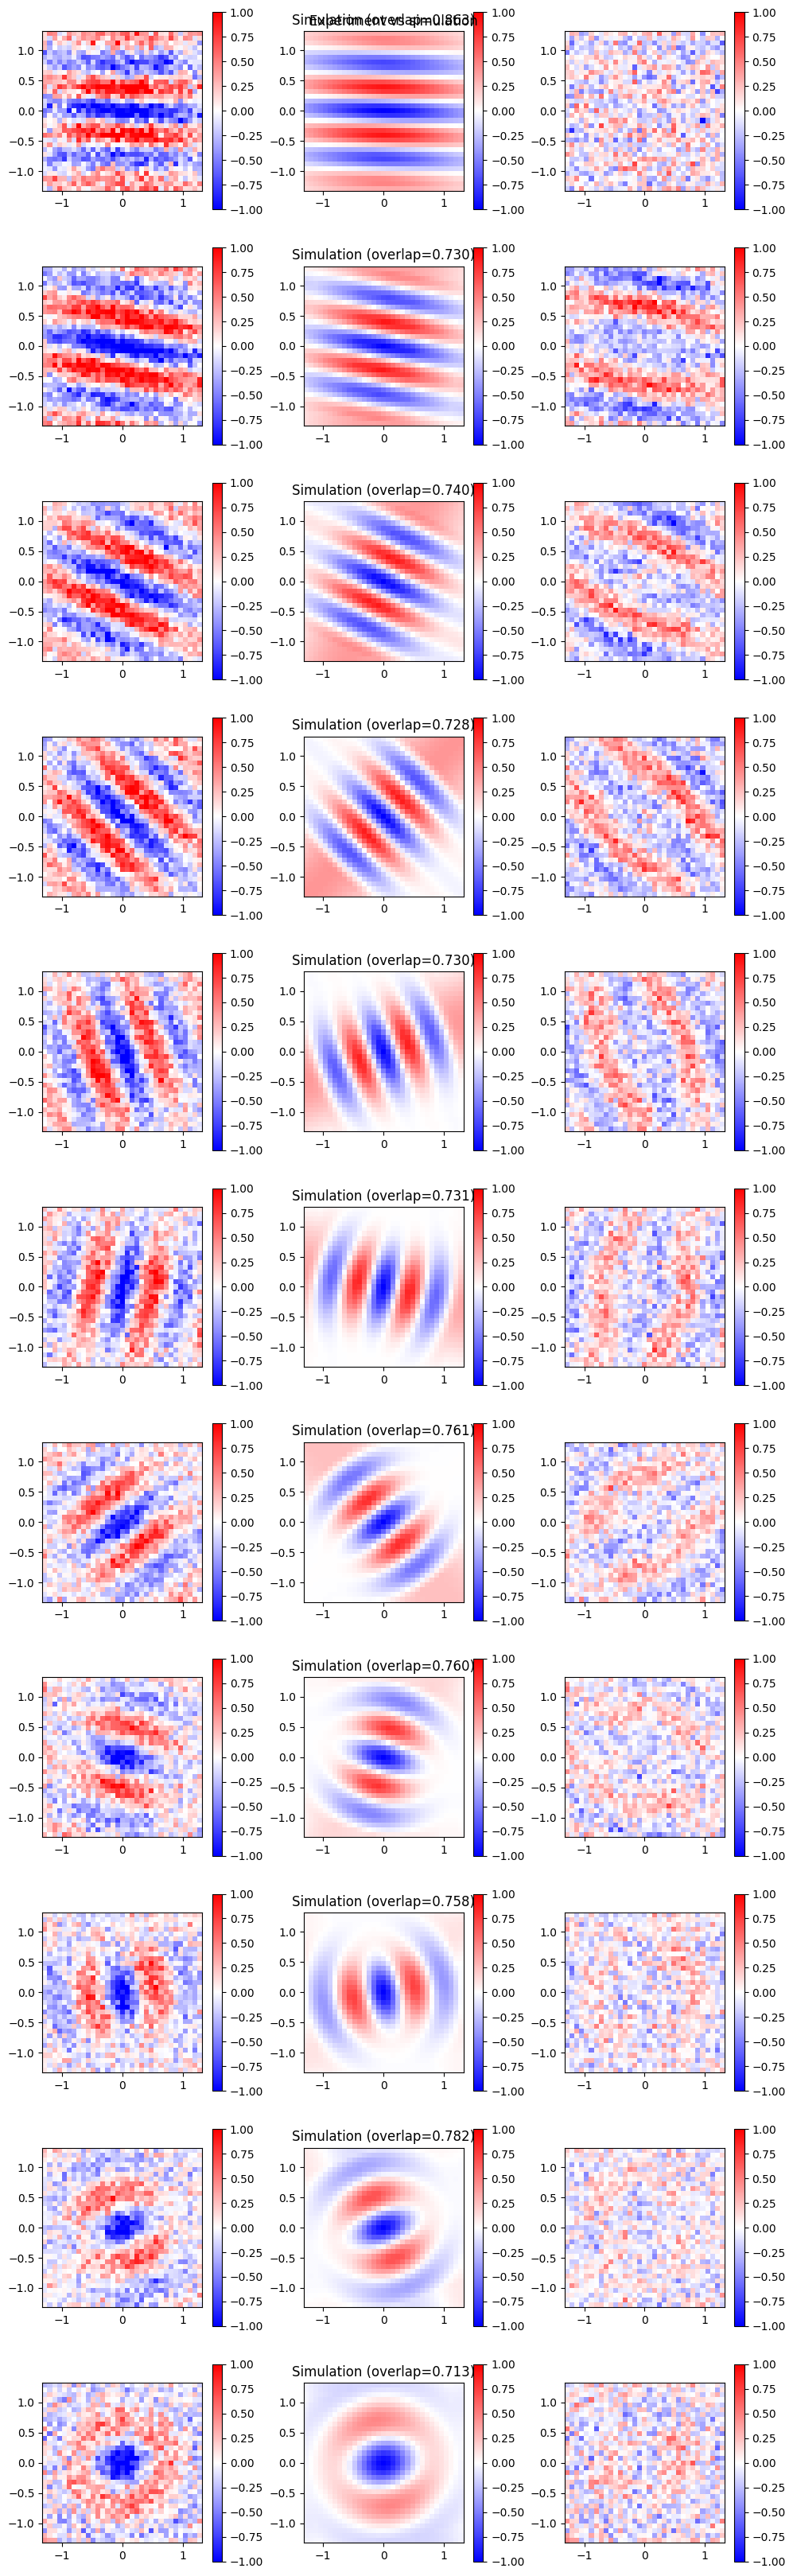

(array([-178., -170., -156., -136., -111.,  -77.,  -37.,   15.,   78.,
         160.,  169.]),
 array([0.86283295, 0.73011314, 0.74002057, 0.72825663, 0.72970504,
        0.73079967, 0.76101685, 0.76049604, 0.75812556, 0.78214047,
        0.71283223]))

In [5]:
T1_values=np.linspace(50_000,400_000,10); T2_values=np.linspace(50_000,400_000,10)
cost=np.empty((len(T1_values),len(T2_values)))
for i,t1 in enumerate(T1_values):
    for j,t2 in enumerate(T2_values):
        sim=simulator.simulate(decay_sweep_sorted,t1,t2,alpha=initial_alpha,return_real=Real_part,return_imag=Imag_part)
        cost[i,j]=residue(exp_data,sim,mask,weights=weights,first_angle=(initial_angle if independent_first else None))
best=np.unravel_index(np.argmin(cost),cost.shape); best_T1,best_T2=T1_values[best[0]],T2_values[best[1]]
best_sim=simulator.simulate(decay_sweep_sorted,best_T1,best_T2,alpha=initial_alpha,return_real=Real_part,return_imag=Imag_part)
best_angles,best_overlaps=extract_rotation_angles(exp_data,best_sim,mask,first_angle=(initial_angle if independent_first else None))
print(f'Grid result: T1={best_T1/1000:.3f} us, T2={best_T2/1000:.3f} us, residue={cost[best]:.6f}')
plot_landscape(cost,T1_values,T2_values,best_T1,best_T2)
compare_experiment_simulation(exp_data,best_sim,x_list,y_list,mask,weights=weights,rotate_images=True,first_angle=(initial_angle if independent_first else None))

## 5. Estimate detuning

angle offset=-180.427 deg, detuning=0.008973 MHz


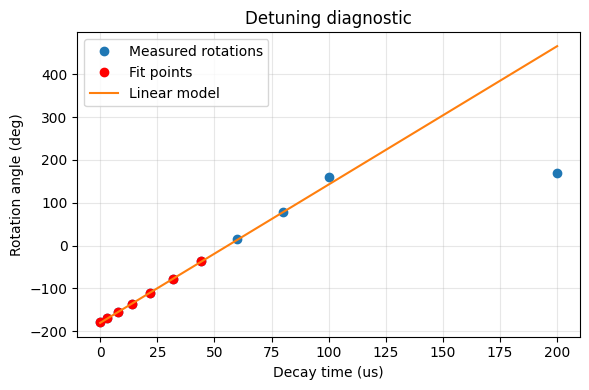

In [6]:
num_points_fit=7; times_us=np.asarray(decay_sweep_sorted)/1000.0
detuning_start = 1 if independent_first else 0
if len(best_angles) - detuning_start < 2: raise ValueError('At least two post-alpha-fit points are required to estimate detuning.')
fit_times=times_us[detuning_start:detuning_start+num_points_fit]
fit_angles=best_angles[detuning_start:detuning_start+num_points_fit].copy()
for i in range(len(fit_angles)):
    while fit_angles[i]-fit_angles[0]>180: fit_angles[i]-=360
    while fit_angles[i]-fit_angles[0]<-180: fit_angles[i]+=360
def angle_model(t,offset,slope): return offset+slope*t
popt,_=curve_fit(angle_model,fit_times,fit_angles); initial_angle_offset,initial_detuning=popt[0],popt[1]/360.0
if independent_first:
    print(f'first-point angle={initial_angle:.3f} deg; prepared-state angle={initial_angle_offset:.3f} deg, detuning={initial_detuning:.6f} MHz')
else:
    print(f'angle offset={initial_angle_offset:.3f} deg, detuning={initial_detuning:.6f} MHz')
plt.figure(figsize=(6,4)); plt.plot(times_us,best_angles,'o',label='Measured rotations'); plt.plot(fit_times,fit_angles,'ro',label='Fit points'); plt.plot(times_us,angle_model(times_us,*popt),'-',label='Linear model'); plt.xlabel('Decay time (us)'); plt.ylabel('Rotation angle (deg)'); plt.title('Detuning diagnostic'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

## 6. Final optimization

In [7]:
fit_T1=True; fixed_T1=376_800; fit_detuning=False
fit=optimize_parameters(simulator,exp_data,decay_sweep_sorted,best_T1,best_T2,initial_detuning,initial_alpha,initial_angle_offset,lambda e,s,rotate_images=False: residue_no_rotation(e,s,mask,weights=weights),fit_T1=fit_T1,fixed_T1=fixed_T1,first_angle=(initial_angle if independent_first else None),component=('real' if Real_part else 'imag'),fit_angle=True,fit_detuning=fit_detuning,maxiter=60)
print(f'Final: T1={fit["T1"]/1000:.3f} us, T2={fit["T2"]/1000:.3f} us, detuning={fit["detuning"]:.6f} MHz, angle={fit["angle"]:.3f} deg, cost={fit["cost"]:.6f}')
compare_experiment_simulation(exp_data,fit['simulation'],x_list,y_list,mask,weights=weights,rotate_images=False)
if len(fit['history']):
    plt.figure(figsize=(6,4)); plt.plot(fit['history'][:,3],'-o',ms=3); plt.xlabel('Evaluation'); plt.ylabel('Cost'); plt.title('Optimization convergence'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

Optimizing T1/T2:  22%|██▏       | 13/60 [00:29<01:17,  1.65s/it]

KeyboardInterrupt: 

In [ ]:
weights

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Fancy plots

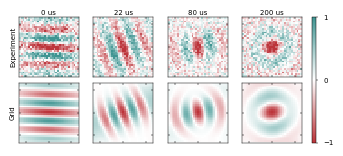

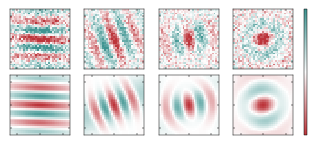

Saved labelled and text-free colour-pair figures to E:\CQT\Fast Flux\coherent_decay_analysis\Figures\fancy_palette_pairs


In [8]:
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.ndimage import rotate as ndimage_rotate
from helpers.comparison import affine_fit

# ----- User controls -----
fancy_fit_source = 'grid'       # 'grid' or 'optimization'
fancy_indices = [0, 4, 8, 10]   # exactly four dataset indices
fancy_component = 'real'        # 'real' or 'imaginary'
fancy_output_dir = Path('Figures/fancy_palette_pairs')

colours = np.array(['#BC343A', '#F19F3C', '#88B742', '#3E9491', '#7C1954'])
# Palette colours 1 and 4 (using the one-based numbering above).
fancy_colour_pair = (0, 3)
fancy_norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

if fancy_fit_source not in {'grid', 'optimization'}:
    raise ValueError("fancy_fit_source must be 'grid' or 'optimization'.")
if fancy_component not in {'real', 'imaginary'}:
    raise ValueError("fancy_component must be 'real' or 'imaginary'.")
if len(fancy_indices) != 4 or len(set(fancy_indices)) != 4:
    raise ValueError('Choose exactly four distinct fancy_indices.')
if min(fancy_indices) < 0 or max(fancy_indices) >= len(decay_sweep_sorted):
    raise IndexError('A fancy plot index lies outside decay_sweep_sorted.')
if fancy_component == 'real' and not Real_part:
    raise ValueError('Real data were not loaded; set Real_part=True or choose imaginary.')
if fancy_component == 'imaginary' and not Imag_part:
    raise ValueError('Imaginary data were not loaded; set Imag_part=True or choose real.')

def _fancy_component(data):
    if isinstance(data, tuple):
        return data[0] if fancy_component == 'real' else data[1]
    return data

raw_experimental_images = _fancy_component(exp_data)
if fancy_fit_source == 'grid':
    grid_images = _fancy_component(best_sim)
    fitted_images = np.asarray([
        ndimage_rotate(grid_images[i], float(best_angles[i]), reshape=False, order=1, mode='nearest')
        for i in range(len(grid_images))
    ])
else:
    fitted_images = _fancy_component(fit['simulation'])

# Match compare_experiment_simulation: calibrate each experimental image to its fit.
experimental_images = np.array(raw_experimental_images, copy=True)
for index in fancy_indices:
    experimental_images[index], _, _ = affine_fit(
        raw_experimental_images[index], fitted_images[index], mask
    )

def _pixel_edges(coordinates):
    coordinates = np.asarray(coordinates, dtype=float)
    if coordinates.ndim != 1 or len(coordinates) < 2:
        raise ValueError('Each fancy-plot coordinate axis must contain at least two points.')
    midpoints = 0.5 * (coordinates[:-1] + coordinates[1:])
    return np.concatenate(([coordinates[0] - (midpoints[0] - coordinates[0])], midpoints,
                           [coordinates[-1] + (coordinates[-1] - midpoints[-1])]))

# Exact PDF canvas width: 8.6 cm. Saving without bbox_inches='tight' preserves it.
CM = 1 / 2.54
fancy_output_dir.mkdir(parents=True, exist_ok=True)
fancy_output_paths = []
negative_colour, positive_colour = fancy_colour_pair
fancy_cmap = LinearSegmentedColormap.from_list(
    f'fancy_{negative_colour}_{positive_colour}',
    [(0.0, colours[negative_colour]), (0.5, '#FFFFFF'), (1.0, colours[positive_colour])],
    N=257,
)
for text_suffix, show_text in [('labelled', True), ('no_text', False)]:
    fig = plt.figure(figsize=(8.6 * CM, 4.1 * CM))
    gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 0.055])
    fig.subplots_adjust(left=0.075, right=0.965, bottom=0.09, top=0.87, wspace=0.12, hspace=0.10)

    image_artist = None
    for column, index in enumerate(fancy_indices):
        x_edges = _pixel_edges(x_list[index])
        y_edges = _pixel_edges(y_list[index])
        extent = (x_edges[0], x_edges[-1], y_edges[0], y_edges[-1])
        for row, image in enumerate((experimental_images[index], fitted_images[index])):
            ax = fig.add_subplot(gs[row, column])
            image_artist = ax.imshow(
                image, origin='lower', extent=extent, interpolation='nearest',
                cmap=fancy_cmap, norm=fancy_norm, aspect='equal', rasterized=True,
            )
            # Explicit limits prevent ticks/aspect handling from exposing blank margins.
            ax.set_xlim(x_edges[0], x_edges[-1])
            ax.set_ylim(y_edges[0], y_edges[-1])
            ax.set(xticks=[-1, 0, 1], yticks=[-1, 0, 1])
            ax.tick_params(
                axis='x', labelbottom=False, bottom=True, top=True,
                width=0.35, length=1.5, direction='in',
            )
            ax.tick_params(
                axis='y', labelleft=False, left=True, right=True,
                width=0.35, length=1.5, direction='in',
            )
            for spine in ax.spines.values():
                spine.set_linewidth(0.35)
            if show_text and row == 0:
                delay_us = float(decay_sweep_sorted[index]) / 1000.0
                ax.set_title(f'{delay_us:g} us', fontsize=5, pad=1.5)
            if show_text and column == 0:
                ax.set_ylabel('Experiment' if row == 0 else fancy_fit_source.capitalize(), fontsize=5, labelpad=2)

    colorbar_ax = fig.add_subplot(gs[:, 4])
    colorbar = fig.colorbar(image_artist, cax=colorbar_ax, ticks=([-1, 0, 1] if show_text else []))
    colorbar.ax.tick_params(labelsize=5, width=0.35, length=1.5)
    colorbar.outline.set_linewidth(0.35)

    output_path = fancy_output_dir / (
        f'fancy_{fancy_fit_source}_{fancy_component}_colours_{negative_colour + 1}_{positive_colour + 1}_{text_suffix}.pdf'
    )
    fig.savefig(output_path, transparent=True)
    fancy_output_paths.append(output_path)
    plt.show()

print(f'Saved labelled and text-free colour-pair figures to {fancy_output_dir.resolve()}')